# Lab 5: Orbital Mechanics Simulator

**Name:** Alex Bebb  
**Course:** PHYS 311 — Classical Mechanics I  
**Date:** September 27, 2026  

## Purpose

I will simulate orbital motion under gravity and compare how different
numerical methods affect the results. I will begin with Velocity
Verlet, then compare it with Euler and Euler-Cromer using the same
initial conditions.

I will track energy and angular momentum to check the simulations
and use the trajectories to test Kepler's three laws.

## Units and model

I will use scaled units in which the gravitational constant is
$G=1$ and the central mass is $M=1$. Distances, times, and velocities
will be reported in these simulation units rather than SI units.

For the main assignment, the central body will remain fixed at the
origin. The orbiting object will move under its gravitational
acceleration, without affecting the central body's motion.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Constants in the scaled units used for this lab.
G = 1.0
M = 1.0

# Default plot appearance.
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["font.size"] = 12
plt.rcParams["axes.grid"] = True

## Part A: A Single Orbit with Velocity Verlet

### Gravitational acceleration

I will model a fixed central body at the origin. Its gravitational
acceleration on the orbiting object is:

$$
\mathbf{a}(\mathbf{r})
=-\frac{GM}{|\mathbf{r}|^3}\mathbf{r}.
$$

The position vector points from the origin toward the orbiting
object, so the negative sign makes the acceleration point back
toward the central body.

Although the denominator contains the distance cubed, the
acceleration's magnitude follows an inverse-square law. The
position vector in the numerator contributes one factor of distance:

$$
|\mathbf{a}|=\frac{GM}{|\mathbf{r}|^2}.
$$

I will use the acceleration formula from the lesson. The function
will reject a position exactly at the origin, where the point-mass
gravitational formula is undefined.

In [2]:
def accel(r):
    """Return gravitational acceleration from the fixed central body."""

    # Calculate the distance from the origin.
    dist = np.linalg.norm(r)

    # The point-mass formula is undefined at zero distance.
    if dist == 0:
        raise ValueError("Gravitational acceleration is undefined at the origin.")

    return -G * M * r / dist**3

### Advancing the orbit with Velocity Verlet

I will use the Velocity Verlet function from the lesson to advance
position and velocity by one time step.

First, it will calculate the new position using the current
position, velocity, and acceleration:

$$
\mathbf{r}_{n+1}
=\mathbf{r}_n+\mathbf{v}_n\Delta t
+\frac{1}{2}\mathbf{a}_n\Delta t^2.
$$

It will then evaluate gravitational acceleration at the new position:

$$
\mathbf{a}_{n+1}=\mathbf{a}(\mathbf{r}_{n+1}).
$$

Finally, it will update velocity using the average of the old and
new accelerations:

$$
\mathbf{v}_{n+1}
=\mathbf{v}_n+\frac{1}{2}
(\mathbf{a}_n+\mathbf{a}_{n+1})\Delta t.
$$

The function will return the new position, velocity, and acceleration.
Keeping the acceleration allows the next step to reuse it.

The acceleration function will be passed as an input, keeping the
integration method separate from the gravitational force model.

In [3]:
def verlet_step(r, v, a, dt, accel_func):
    """Advance position and velocity by one Velocity Verlet step."""

    # Update position using the current velocity and acceleration.
    r_new = r + v * dt + 0.5 * a * dt**2

    # Calculate acceleration at the new position.
    a_new = accel_func(r_new)

    # Update velocity using the average acceleration.
    v_new = v + 0.5 * (a + a_new) * dt

    return r_new, v_new, a_new

### Energy and angular momentum

I will calculate energy and angular momentum per unit mass to
check whether the simulated orbit follows the expected conservation
laws. These are called specific energy and specific angular momentum.

The specific mechanical energy is:

$$
\varepsilon=\frac{1}{2}|\mathbf{v}|^2-\frac{GM}{|\mathbf{r}|}.
$$

The first term is kinetic energy per unit mass. The second is
gravitational potential energy per unit mass, with zero potential
energy defined at infinite distance. A negative total indicates
a bound orbit.

For motion in the xy-plane, the perpendicular component of
specific angular momentum is:

$$
h_z=xv_y-yv_x.
$$

Gravity points toward the origin, so it produces no torque about
the origin. Therefore, angular momentum should remain constant.
Mechanical energy should also remain constant in the exact motion,
although the numerical method can introduce small errors.

These quantities have units of length squared divided by time
squared for specific energy, and length squared divided by time
for specific angular momentum. I will report them in the scaled
units used for this simulation.

In [4]:
def specific_energy(r, v):
    """Return mechanical energy per unit orbiting mass."""

    kinetic = 0.5 * np.dot(v, v)
    potential = -G * M / np.linalg.norm(r)

    return kinetic + potential


def specific_ang_momentum(r, v):
    """Return the z-component of angular momentum per unit mass."""

    return r[0] * v[1] - r[1] * v[0]

### Initial conditions and expected values

I will start the object at:

$$
\mathbf{r}_0=(1.0,\ 0.0),
\qquad
\mathbf{v}_0=(0.0,\ 0.8).
$$

The initial velocity is perpendicular to the position vector.
At this distance, the circular speed is:

$$
v_{\mathrm{circ}}=\sqrt{\frac{GM}{r_0}}=1.0.
$$

The initial speed is below the circular speed, so the object
starts at apoapsis, the farthest point of its elliptical orbit.
It will initially move inward rather than maintain a constant
distance from the star.

The expected initial specific energy and angular momentum are:

$$
\varepsilon_0=\frac{1}{2}(0.8)^2-1=-0.68,
$$

$$
h_{z,0}=(1.0)(0.8)-(0.0)(0.0)=0.8.
$$

I will use a time step of 0.001 and 20,000 steps, giving a total
duration of 20 simulation time units.

In [5]:
# Initial position and velocity in scaled simulation units.
r0 = np.array([1.0, 0.0])
v0 = np.array([0.0, 0.8])

dt = 0.001
n_steps = 20000

# Calculate initial acceleration and diagnostic values.
a0 = accel(r0)
energy0 = specific_energy(r0, v0)
h0 = specific_ang_momentum(r0, v0)

circular_speed = np.sqrt(G * M / np.linalg.norm(r0))

print("Initial acceleration:", a0)
print(f"Initial speed: {np.linalg.norm(v0):.4f}")
print(f"Circular speed at the initial position: {circular_speed:.4f}")
print(f"Initial specific energy: {energy0:.6f}")
print(f"Initial specific angular momentum: {h0:.6f}")
print(f"Simulation duration: {n_steps * dt:.3f} time units")

Initial acceleration: [-1. -0.]
Initial speed: 0.8000
Circular speed at the initial position: 1.0000
Initial specific energy: -0.680000
Initial specific angular momentum: 0.800000
Simulation duration: 20.000 time units


### Running the orbit simulation

I will advance the orbit using Velocity Verlet for 20,000 time
steps. At each step, the algorithm will update position, calculate
the new gravitational acceleration, and then update velocity.

I will store the initial state and each subsequent state, including
specific energy and specific angular momentum. This will allow me
to check conservation throughout the orbit.

I will plot the trajectory with equal scales on both axes so the
orbital shape is not distorted. The central body will be marked
at the origin, which should lie at one focus of the ellipse.

Over this run, the trajectory should approximately retrace the
same ellipse rather than spiral inward or outward.

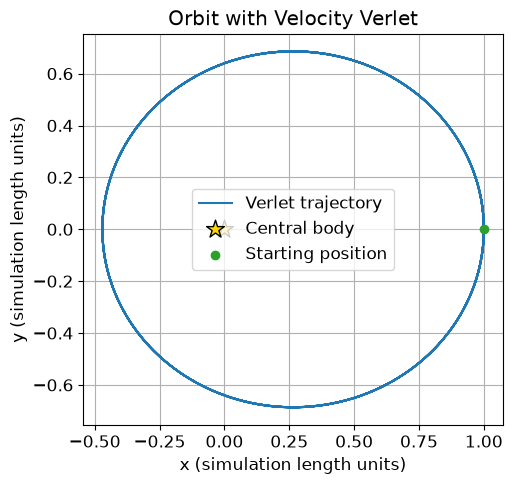

Stored time points: 20001
Final stored time: 20.000
Initial specific energy: -0.680000
Final specific energy: -0.680000


In [6]:
# Copy the initial state so r0 and v0 remain unchanged.
r = r0.copy()
v = v0.copy()
a = accel(r)

# Store the initial state.
positions = [r.copy()]
velocities = [v.copy()]
energies = [specific_energy(r, v)]
angular_momenta = [specific_ang_momentum(r, v)]

# Advance the orbit and save the results after every step.
for step in range(n_steps):
    r, v, a = verlet_step(r, v, a, dt, accel)

    positions.append(r.copy())
    velocities.append(v.copy())
    energies.append(specific_energy(r, v))
    angular_momenta.append(specific_ang_momentum(r, v))

# Convert the lists into arrays for calculations and plotting.
positions = np.array(positions)
velocities = np.array(velocities)
energies = np.array(energies)
angular_momenta = np.array(angular_momenta)

time = np.arange(n_steps + 1) * dt

# Keep this run together for later comparisons.
orbit_verlet = {
    "time": time,
    "positions": positions,
    "velocities": velocities,
    "energy": energies,
    "angular_momentum": angular_momenta,
}

# Plot the orbital path and mark the central body.
fig, ax = plt.subplots()

ax.plot(positions[:, 0], positions[:, 1], label="Verlet trajectory")
ax.scatter(
    0, 0, marker="*", s=180, color="gold",
    edgecolors="black", label="Central body", zorder=3,
)
ax.scatter(
    r0[0], r0[1], color="tab:green",
    label="Starting position", zorder=3,
)

ax.set(
    xlabel="x (simulation length units)",
    ylabel="y (simulation length units)",
    title="Orbit with Velocity Verlet",
)
ax.set_aspect("equal", adjustable="box")
ax.legend()

plt.tight_layout()
plt.show()

print(f"Stored time points: {len(time)}")
print(f"Final stored time: {time[-1]:.3f}")
print(f"Initial specific energy: {energies[0]:.6f}")
print(f"Final specific energy: {energies[-1]:.6f}")

### Checking energy and angular momentum conservation

I will plot specific energy and specific angular momentum throughout
the simulation and compare them with their initial values.

For the exact orbit, both quantities are constant. Velocity Verlet
should keep the energy error small and bounded with this time step.
For a central force, it also preserves angular momentum up to
floating-point rounding.

I will calculate the maximum fractional deviations:

$$
\max\left|\frac{\varepsilon(t)-\varepsilon_0}{\varepsilon_0}\right|,
$$

$$
\max\left|\frac{h_z(t)-h_{z,0}}{h_{z,0}}\right|.
$$

These calculations check the entire run. Comparing only the initial
and final values could miss errors that grew and then decreased
between those times.

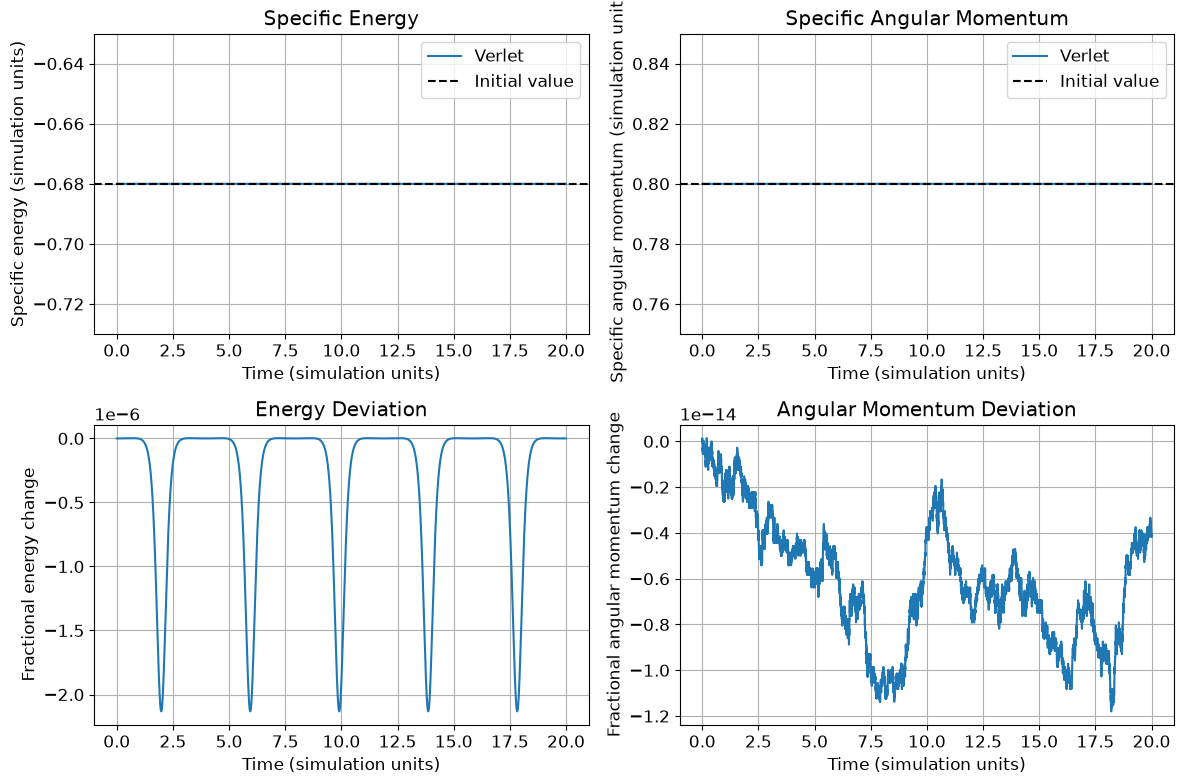

Maximum fractional energy error: 2.132e-06
Maximum fractional angular momentum error: 1.180e-14


In [7]:
# Retrieve the results of the Part A orbit.
time = orbit_verlet["time"]
energy = orbit_verlet["energy"]
h = orbit_verlet["angular_momentum"]

# Calculate signed fractional changes from the initial values.
energy_change = (energy - energy[0]) / abs(energy[0])
h_change = (h - h[0]) / abs(h[0])

max_energy_error = np.max(np.abs(energy_change))
max_h_error = np.max(np.abs(h_change))

# Show the physical quantities and their small numerical deviations.
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(time, energy, label="Verlet")
axes[0, 0].axhline(
    energy[0], color="black", linestyle="--", label="Initial value"
)
axes[0, 0].set(
    ylabel="Specific energy (simulation units)",
    title="Specific Energy",
    ylim=(energy[0] - 0.05, energy[0] + 0.05),
)
axes[0, 0].legend()

axes[0, 1].plot(time, h, label="Verlet")
axes[0, 1].axhline(
    h[0], color="black", linestyle="--", label="Initial value"
)
axes[0, 1].set(
    ylabel="Specific angular momentum (simulation units)",
    title="Specific Angular Momentum",
    ylim=(h[0] - 0.05, h[0] + 0.05),
)
axes[0, 1].legend()

axes[1, 0].plot(time, energy_change)
axes[1, 0].set(
    ylabel="Fractional energy change",
    title="Energy Deviation",
)

axes[1, 1].plot(time, h_change)
axes[1, 1].set(
    ylabel="Fractional angular momentum change",
    title="Angular Momentum Deviation",
)

for ax in axes.flat:
    ax.set_xlabel("Time (simulation units)")

plt.tight_layout()
plt.show()

print(f"Maximum fractional energy error: {max_energy_error:.3e}")
print(f"Maximum fractional angular momentum error: {max_h_error:.3e}")

### Part A interpretation

The trajectory formed an ellipse that closely retraced itself over
several orbits, with the central body at one focus. There was no
obvious inward or outward spiral.

The starting point was apoapsis. The initial velocity was entirely
tangential, and its magnitude of 0.8 was below the circular speed
of 1.0 at that distance. The object therefore moved closer to the
central body before returning to its maximum distance.

Specific energy stayed close to -0.68, with small repeating
numerical variations. Specific angular momentum stayed close to
0.8, with deviations near floating-point precision.

These results support the accuracy of the orbit over the simulated
interval. However, conservation checks and a visually closed path
do not prove that the position and orbital period are exact.
A smaller-time-step comparison can test those errors further.

## Part B: Comparing Numerical Integration Methods

### A reusable orbit simulator

I will adapt the simulation loop from Part A so it can use Euler,
Euler-Cromer, or Velocity Verlet. All three methods will use the
same gravitational acceleration and diagnostic functions.

The main difference is how they update position and velocity.

Standard Euler uses the current velocity to update position and
the current acceleration to update velocity:

$$
\mathbf{r}_{n+1}=\mathbf{r}_n+\mathbf{v}_n\Delta t,
$$

$$
\mathbf{v}_{n+1}=\mathbf{v}_n+\mathbf{a}_n\Delta t.
$$

Euler-Cromer updates velocity first, then uses that new velocity
to update position:

$$
\mathbf{v}_{n+1}=\mathbf{v}_n+\mathbf{a}_n\Delta t,
$$

$$
\mathbf{r}_{n+1}=\mathbf{r}_n+\mathbf{v}_{n+1}\Delta t.
$$

For Velocity Verlet, I will call the function already defined
in Part A.

The simulator will store time, position, velocity, specific energy,
and specific angular momentum. Optional initial-condition inputs
will allow me to reuse it for different orbits later.

In [8]:
def simulate(method, dt, n_steps, r_initial=None, v_initial=None):
    """Simulate a fixed-star orbit using the selected integration method."""

    allowed_methods = ("euler", "euler-cromer", "verlet")
    if method not in allowed_methods:
        raise ValueError(f"Choose a method from {allowed_methods}.")

    # Use the assignment's initial conditions unless others are supplied.
    if r_initial is None:
        r_initial = [1.0, 0.0]
    if v_initial is None:
        v_initial = [0.0, 0.8]

    # Create independent floating-point arrays for this run.
    r = np.array(r_initial, dtype=float, copy=True)
    v = np.array(v_initial, dtype=float, copy=True)
    a = accel(r)

    # Store the initial state.
    positions = [r.copy()]
    velocities = [v.copy()]
    energies = [specific_energy(r, v)]
    angular_momenta = [specific_ang_momentum(r, v)]

    for step in range(n_steps):

        if method == "euler":
            # Position uses the old velocity.
            r_new = r + v * dt
            v_new = v + a * dt

            r = r_new
            v = v_new
            a = accel(r)

        elif method == "euler-cromer":
            # Position uses the newly updated velocity.
            v = v + a * dt
            r = r + v * dt
            a = accel(r)

        else:
            # Reuse the Velocity Verlet function from Part A.
            r, v, a = verlet_step(r, v, a, dt, accel)

        # Save the updated state, regardless of the chosen method.
        positions.append(r.copy())
        velocities.append(v.copy())
        energies.append(specific_energy(r, v))
        angular_momenta.append(specific_ang_momentum(r, v))

    return {
        "time": np.arange(n_steps + 1) * dt,
        "positions": np.array(positions),
        "velocities": np.array(velocities),
        "energy": np.array(energies),
        "angular_momentum": np.array(angular_momenta),
    }

### Comparing the orbital trajectories

I will run Euler, Euler-Cromer, and Velocity Verlet using the same
initial position, initial velocity, time step, and duration.

Each simulation will start at $(1,0)$ with velocity $(0,0.8)$.
I will use a time step of 0.001 for 100,000 steps, giving a total
duration of 100 simulation time units.

Holding these settings constant isolates the effect of the
integration method. I will overlay the trajectories with equal
axis scales to compare their shapes.

I expect Euler's numerical errors to substantially change the
orbit over time. Euler-Cromer and Verlet should keep the motion
bounded, with Verlet more accurately preserving the original
ellipse at this time step.

Finished: Euler
Finished: Euler-Cromer
Finished: Velocity Verlet


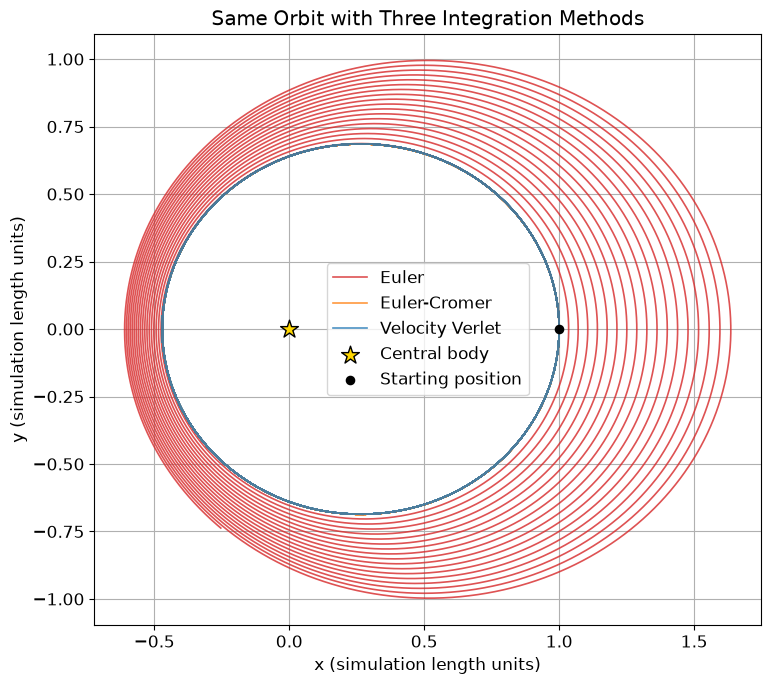


Time step: 0.001
Duration: 100.0 time units


In [9]:
# Use identical settings for all three methods.
comparison_dt = 0.001
comparison_steps = 100000

methods = ["euler", "euler-cromer", "verlet"]

method_labels = {
    "euler": "Euler",
    "euler-cromer": "Euler-Cromer",
    "verlet": "Velocity Verlet",
}

method_colors = {
    "euler": "tab:red",
    "euler-cromer": "tab:orange",
    "verlet": "tab:blue",
}

# Run each method and keep its results.
comparison_results = {}

for method in methods:
    comparison_results[method] = simulate(
        method=method,
        dt=comparison_dt,
        n_steps=comparison_steps,
        r_initial=r0,
        v_initial=v0,
    )

    print(f"Finished: {method_labels[method]}")

# Overlay the three trajectories.
fig, ax = plt.subplots(figsize=(9, 7))

for method in methods:
    path = comparison_results[method]["positions"]

    ax.plot(
        path[:, 0],
        path[:, 1],
        color=method_colors[method],
        label=method_labels[method],
        linewidth=1.2,
        alpha=0.8,
    )

ax.scatter(
    0, 0,
    marker="*",
    s=180,
    color="gold",
    edgecolors="black",
    label="Central body",
    zorder=5,
)

ax.scatter(
    r0[0], r0[1],
    color="black",
    s=35,
    label="Starting position",
    zorder=5,
)

ax.set(
    xlabel="x (simulation length units)",
    ylabel="y (simulation length units)",
    title="Same Orbit with Three Integration Methods",
)
ax.set_aspect("equal", adjustable="box")
ax.legend()

plt.tight_layout()
plt.show()

print(f"\nTime step: {comparison_dt}")
print(f"Duration: {comparison_dt * comparison_steps:.1f} time units")

### Comparing energy errors

I will plot specific energy against time for all three methods.
The exact value should remain at its initial value of -0.68.

I will also plot the fractional energy changes for Euler-Cromer
and Verlet separately from Euler so their smaller errors remain
visible.

For each method, I will report the maximum fractional energy error:

$$
\delta_{\max}
=\max_t\left|\frac{\varepsilon(t)-\varepsilon_0}
{\varepsilon_0}\right|.
$$

Because the orbiting mass is constant, the fractional error in
specific energy is the same as the fractional error in total
mechanical energy.

This comparison uses the same time step, duration, and initial
conditions for every method.

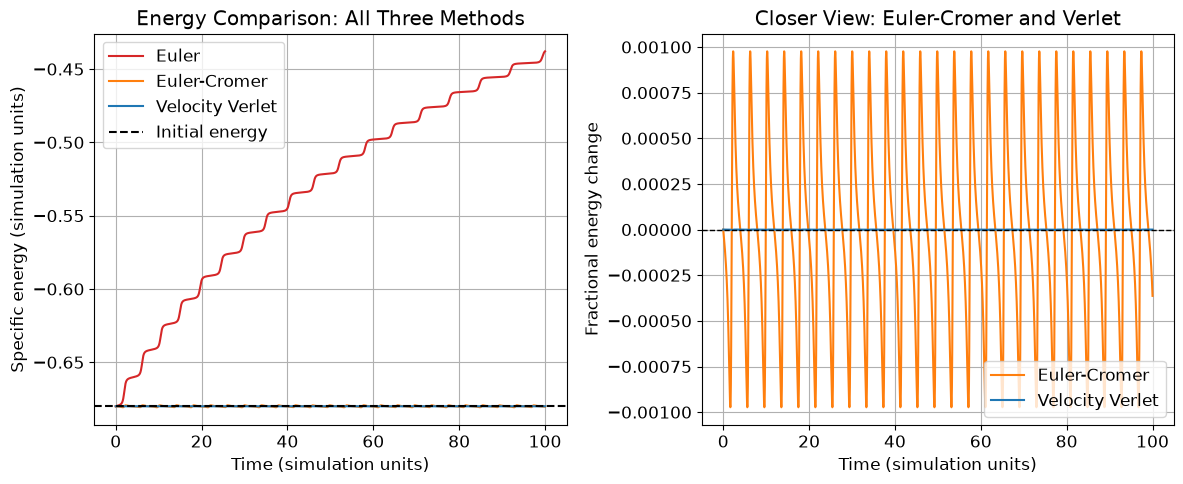

Method                Max fractional error      Max error (%)
-------------------------------------------------------------
Euler                         3.560416e-01          35.604155
Euler-Cromer                  9.763463e-04           0.097635
Velocity Verlet               2.131864e-06           0.000213


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Store the maximum fractional error for each method.
energy_errors = {}

for method in methods:
    results = comparison_results[method]
    t = results["time"]
    energy = results["energy"]

    fractional_change = (energy - energy[0]) / abs(energy[0])
    energy_errors[method] = np.max(np.abs(fractional_change))

    # Compare all three energy histories.
    axes[0].plot(
        t,
        energy,
        color=method_colors[method],
        label=method_labels[method],
    )

    # Show the smaller errors without Euler setting the vertical scale.
    if method != "euler":
        axes[1].plot(
            t,
            fractional_change,
            color=method_colors[method],
            label=method_labels[method],
        )

initial_energy = comparison_results["verlet"]["energy"][0]

axes[0].axhline(
    initial_energy,
    color="black",
    linestyle="--",
    label="Initial energy",
)
axes[0].set(
    xlabel="Time (simulation units)",
    ylabel="Specific energy (simulation units)",
    title="Energy Comparison: All Three Methods",
)
axes[0].legend()

axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set(
    xlabel="Time (simulation units)",
    ylabel="Fractional energy change",
    title="Closer View: Euler-Cromer and Verlet",
)
axes[1].legend()

plt.tight_layout()
plt.show()

# Print the required summary table.
print(
    f"{'Method':<18} {'Max fractional error':>23} "
    f"{'Max error (%)':>18}"
)
print("-" * 61)

for method in methods:
    error = energy_errors[method]

    print(
        f"{method_labels[method]:<18} "
        f"{error:>23.6e} {100 * error:>18.6f}"
    )

### Part B interpretation

Using the same initial conditions, time step, and duration produced
very different results depending on the integration method.

| Method | Maximum fractional energy error | Maximum error (%) |
|---|---:|---:|
| Euler | 3.560416e-01 | 35.604155 |
| Euler-Cromer | 9.763463e-04 | 0.097635 |
| Velocity Verlet | 2.131864e-06 | 0.000213 |

Euler's energy became progressively less negative, and its orbit
expanded outward. Its position and velocity updates use only the
old state and do not preserve the Hamiltonian structure of the
motion. For this orbit, the resulting errors accumulated as an
artificial energy gain.

Euler-Cromer's energy oscillated around the initial value.
Velocity Verlet had much smaller energy variations at the same
time step.

Euler-Cromer and Verlet are symplectic methods for this system:
they preserve the geometric structure of Hamiltonian motion in
position-momentum space. With a sufficiently small fixed time step,
this generally produces bounded energy errors over long runs
rather than the systematic drift seen here with Euler.

Symplectic does not mean that energy is conserved exactly.
Euler-Cromer is first-order accurate, while Verlet is second-order
and time-reversible. Verlet's higher accuracy and symplectic
structure help explain its performance in this comparison.

### Try it: Circular, elliptical, and escaping trajectories

I will use Velocity Verlet to compare three initial speeds at
the same starting position, $(1,0)$. Each initial velocity will
point in the positive y direction.

At this distance, the circular and escape speeds are:

$$
v_{\mathrm{circ}}=\sqrt{\frac{GM}{r_0}}=1,
$$

$$
v_{\mathrm{esc}}=\sqrt{\frac{2GM}{r_0}}=\sqrt{2}\approx1.414.
$$

I therefore expect these outcomes:

- An initial speed of 1.0 should produce a circular orbit.
- An initial speed of 0.8 should produce an ellipse.
- An initial speed of 1.5 should produce an unbound hyperbolic path.

I will plot all three trajectories together and include a closer
view near the central body so the escaping trajectory does not
make the bound orbits difficult to see.

  Initial speed    Initial specific energy
            1.0                  -0.500000
            0.8                  -0.680000
            1.5                   0.125000


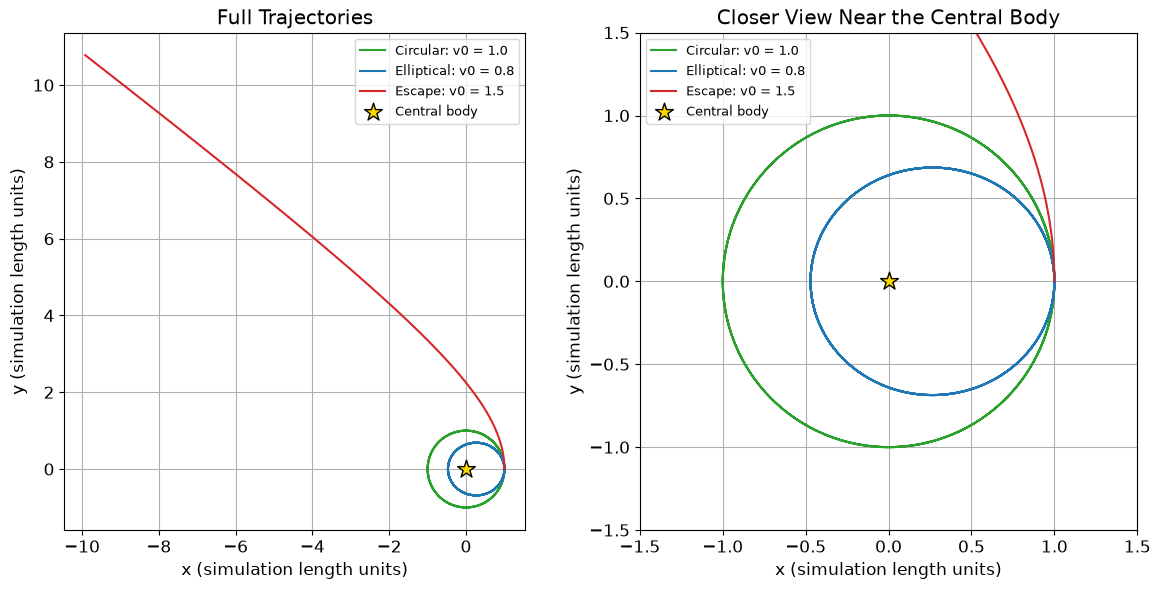

In [11]:
# Compare three speeds using the same starting position.
speed_cases = [
    (1.0, "Circular: v0 = 1.0", "tab:green"),
    (0.8, "Elliptical: v0 = 0.8", "tab:blue"),
    (1.5, "Escape: v0 = 1.5", "tab:red"),
]

try_results = {}

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

print(f"{'Initial speed':>15} {'Initial specific energy':>26}")

for speed, label, color in speed_cases:
    results = simulate(
        method="verlet",
        dt=0.001,
        n_steps=20000,
        r_initial=[1.0, 0.0],
        v_initial=[0.0, speed],
    )

    try_results[speed] = results
    path = results["positions"]

    # Draw the same trajectories in both views.
    for ax in axes:
        ax.plot(path[:, 0], path[:, 1], color=color, label=label)

    print(f"{speed:>15.1f} {results['energy'][0]:>26.6f}")

for ax in axes:
    ax.scatter(
        0, 0,
        marker="*",
        s=180,
        color="gold",
        edgecolors="black",
        label="Central body",
        zorder=5,
    )
    ax.set_xlabel("x (simulation length units)")
    ax.set_ylabel("y (simulation length units)")
    ax.set_aspect("equal", adjustable="box")
    ax.legend(fontsize=9)

axes[0].set_title("Full Trajectories")

axes[1].set(
    title="Closer View Near the Central Body",
    xlim=(-1.5, 1.5),
    ylim=(-1.5, 1.5),
)

plt.tight_layout()
plt.show()

### Try it interpretation

Changing only the initial speed produced the three expected types
of motion. At a speed of 1.0, the trajectory was approximately
circular. At 0.8, it was elliptical, starting at apoapsis.

The speed of 1.5 exceeded the escape speed of approximately 1.414.
Its trajectory curved around the central body and continued
outward instead of forming a closed orbit.

The circular and elliptical cases had negative specific energies,
while the escaping case had positive specific energy. These
results agree with the classification of Newtonian gravitational
orbits by energy.

## Part C: Testing Kepler's Three Laws

### First law: Elliptical orbits

Kepler's first law states that a bound orbit is an ellipse with
the central body at one focus.

I will use the stored Verlet trajectory to estimate the closest
and farthest distances from the central body. These are the
periapsis distance, $r_p$, and apoapsis distance, $r_a$.

For an ellipse, the semi-major axis and eccentricity are:

$$
a_{\mathrm{orbit}}=\frac{r_p+r_a}{2},
$$

$$
e_{\mathrm{orbit}}=\frac{r_a-r_p}{r_a+r_p}.
$$

Here, eccentricity describes the shape of the orbit; it is unrelated
to the coefficient of restitution used in the previous lab.

I will also compare the measured semi-major axis with the value
predicted from the initial specific energy:

$$
a_{\mathrm{theory}}=-\frac{GM}{2\varepsilon_0}.
$$

For these initial conditions, the predicted semi-major axis is
approximately 0.735294, and the eccentricity is 0.36.

To check the shape, I will overlay the numerical trajectory with
the ellipse predicted from the initial conditions. All lengths
are in simulation units.

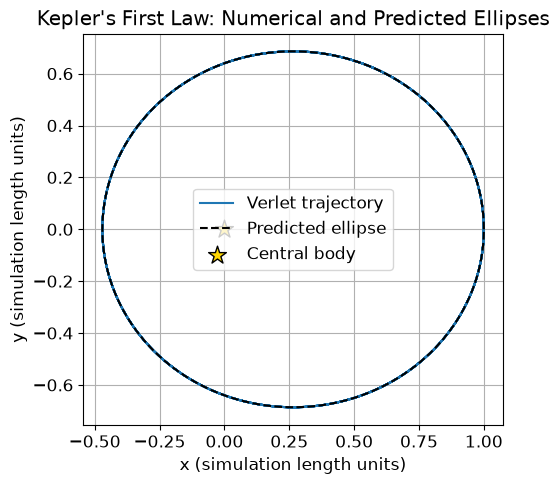

Measured periapsis distance: 0.470589
Measured apoapsis distance: 1.000000
Measured semi-major axis: 0.735295
Predicted semi-major axis: 0.735294
Measured eccentricity: 0.359999
Predicted eccentricity: 0.360000
Semi-major axis percentage error: 0.000061%


In [12]:
# Reuse the orbit from Part A.
path = orbit_verlet["positions"]

# Calculate the distance from the origin at every stored time.
distances = np.linalg.norm(path, axis=1)

periapsis = np.min(distances)
apoapsis = np.max(distances)

# Estimate the ellipse's geometry from the trajectory.
a_measured = 0.5 * (periapsis + apoapsis)
e_measured = (apoapsis - periapsis) / (apoapsis + periapsis)

# Predict the geometry independently from the initial conditions.
initial_energy = specific_energy(r0, v0)
initial_h = specific_ang_momentum(r0, v0)

a_theory = -G * M / (2 * initial_energy)
e_theory = np.sqrt(
    1 + 2 * initial_energy * initial_h**2 / (G * M)**2
)
b_theory = a_theory * np.sqrt(1 - e_theory**2)

# This orbit starts at apoapsis on the positive x-axis.
# Its ellipse center is therefore at x = a * e.
angle = np.linspace(0, 2 * np.pi, 500)
ellipse_x = a_theory * e_theory + a_theory * np.cos(angle)
ellipse_y = b_theory * np.sin(angle)

fig, ax = plt.subplots()

ax.plot(path[:, 0], path[:, 1], label="Verlet trajectory")
ax.plot(
    ellipse_x,
    ellipse_y,
    "k--",
    label="Predicted ellipse",
)
ax.scatter(
    0, 0,
    marker="*",
    s=180,
    color="gold",
    edgecolors="black",
    label="Central body",
    zorder=5,
)

ax.set(
    xlabel="x (simulation length units)",
    ylabel="y (simulation length units)",
    title="Kepler's First Law: Numerical and Predicted Ellipses",
)
ax.set_aspect("equal", adjustable="box")
ax.legend()

plt.tight_layout()
plt.show()

print(f"Measured periapsis distance: {periapsis:.6f}")
print(f"Measured apoapsis distance: {apoapsis:.6f}")
print(f"Measured semi-major axis: {a_measured:.6f}")
print(f"Predicted semi-major axis: {a_theory:.6f}")
print(f"Measured eccentricity: {e_measured:.6f}")
print(f"Predicted eccentricity: {e_theory:.6f}")

a_percent_error = 100 * abs(a_measured - a_theory) / a_theory
print(f"Semi-major axis percentage error: {a_percent_error:.6f}%")

### Second law: Equal areas in equal times

The line connecting the central body to the orbiting object should
sweep out equal areas during equal time intervals.

The instantaneous rate at which area is swept out is:

$$
\frac{dA}{dt}=\frac{1}{2}|\mathbf{r}\times\mathbf{v}|
=\frac{1}{2}|h_z|.
$$

Following the assignment, I will calculate the area swept per
time step using:

$$
\Delta A\approx\frac{1}{2}|xv_y-yv_x|\Delta t.
$$

This estimates the area using the instantaneous areal velocity.
For the exact orbit, the areal velocity is constant, making this
relationship exact over any time interval.

Since $h_{z,0}=0.8$ and $\Delta t=0.001$, the expected area per
step is:

$$
\Delta A=\frac{1}{2}(0.8)(0.001)=0.0004.
$$

Equal areas in equal times follow directly from angular-momentum
conservation, because the areal velocity is half the magnitude
of the specific angular momentum.

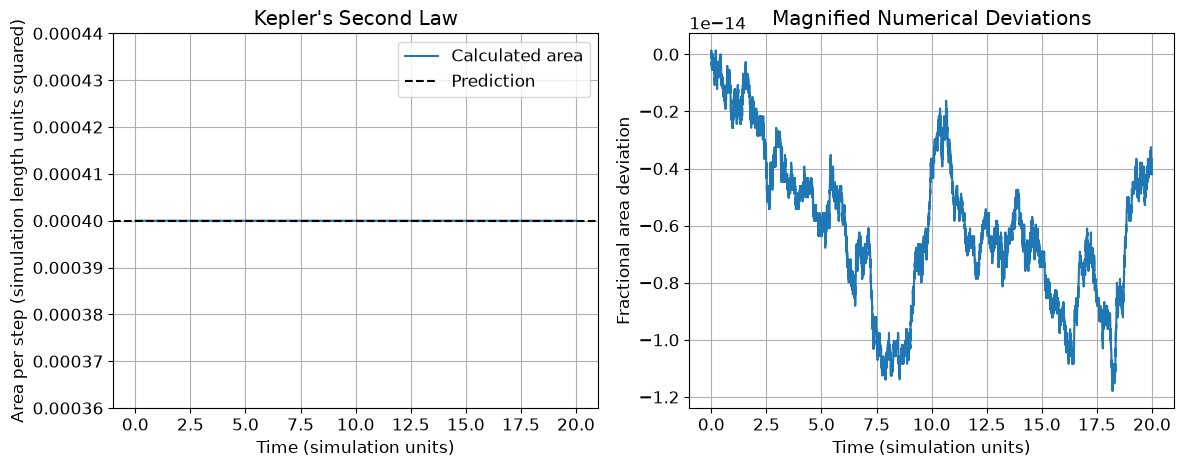

Expected area per step: 0.00040000
Mean calculated area per step: 0.00040000
Maximum fractional area deviation: 1.179e-14


In [13]:
# Retrieve the Part A positions, velocities, and times.
path = orbit_verlet["positions"]
velocity = orbit_verlet["velocities"]
time = orbit_verlet["time"]

# Determine the time step from the stored times.
orbit_dt = time[1] - time[0]

# Calculate the 2D cross product at the start of each interval.
cross_rv = (
    path[:-1, 0] * velocity[:-1, 1]
    - path[:-1, 1] * velocity[:-1, 0]
)

# Estimate the area swept during each time step.
area_per_step = 0.5 * np.abs(cross_rv) * orbit_dt

expected_area = (
    0.5 * abs(specific_ang_momentum(r0, v0)) * orbit_dt
)

fractional_area_change = (
    area_per_step - expected_area
) / expected_area

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(time[:-1], area_per_step, label="Calculated area")
axes[0].axhline(
    expected_area,
    color="black",
    linestyle="--",
    label="Prediction",
)
axes[0].set(
    xlabel="Time (simulation units)",
    ylabel="Area per step (simulation length units squared)",
    title="Kepler's Second Law",
    ylim=(0.9 * expected_area, 1.1 * expected_area),
)
axes[0].legend()

axes[1].plot(time[:-1], fractional_area_change)
axes[1].set(
    xlabel="Time (simulation units)",
    ylabel="Fractional area deviation",
    title="Magnified Numerical Deviations",
)

plt.tight_layout()
plt.show()

print(f"Expected area per step: {expected_area:.8f}")
print(f"Mean calculated area per step: {np.mean(area_per_step):.8f}")
print(
    "Maximum fractional area deviation: "
    f"{np.max(np.abs(fractional_area_change)):.3e}"
)

### Third law: Measuring orbital periods

Kepler's third law predicts:

$$
T^2=\frac{4\pi^2}{GM}a_{\mathrm{orbit}}^3.
$$

I will measure the period and semi-major axis from several simulated
orbits rather than use this equation to generate their periods.

To measure a period, I will detect when the y-coordinate crosses
zero from negative to positive. Successive crossings in the same
direction represent approximately one complete revolution.

A crossing usually occurs between stored time points. I will use
linear interpolation to estimate its time:

$$
t_{\mathrm{cross}}
=t_i-\frac{y_i}{y_{i+1}-y_i}(t_{i+1}-t_i).
$$

I will average the intervals between successive crossings to
estimate the period. The semi-major axis will be estimated from
the minimum and maximum distances from the central body.

Small numerical precession can affect these crossing-based periods,
so they remain numerical estimates rather than exact periods.

In [14]:
def measure_orbit(results):
    """Estimate the period and semi-major axis from a simulated orbit."""

    time = results["time"]
    path = results["positions"]
    y = path[:, 1]

    crossing_times = []

    # Find upward crossings of y = 0.
    for i in range(len(time) - 1):
        if y[i] < 0 and y[i + 1] >= 0:

            # Estimate where the crossing falls within this time interval.
            fraction = -y[i] / (y[i + 1] - y[i])
            crossing_time = (
                time[i] + fraction * (time[i + 1] - time[i])
            )

            crossing_times.append(crossing_time)

    crossing_times = np.array(crossing_times)

    if len(crossing_times) < 2:
        raise ValueError(
            "Not enough upward crossings. Run the simulation for longer."
        )

    # Differences between consecutive crossing times give period estimates.
    measured_periods = np.diff(crossing_times)
    period = np.mean(measured_periods)

    # Estimate the semi-major axis from the radial extremes.
    distances = np.linalg.norm(path, axis=1)
    semi_major_axis = 0.5 * (
        np.min(distances) + np.max(distances)
    )

    return {
        "period": period,
        "semi_major_axis": semi_major_axis,
        "period_samples": measured_periods,
        "crossing_times": crossing_times,
    }

### Testing the period–size relationship

I will simulate five orbits starting at $(1,0)$ with initial
velocities in the positive y direction. Their initial speeds
will be 0.7, 0.8, 0.9, 1.0, and 1.1.

All five speeds are below the escape speed of approximately 1.414,
so all five trajectories should be bound. Each simulation will
use Velocity Verlet with a time step of 0.001 for 60 time units,
allowing several complete revolutions.

I will measure each period and semi-major axis from the trajectory,
then plot $T^2$ against $a^3$.

Kepler's third law predicts a straight line through the origin
with slope:

$$
s_{\mathrm{theory}}=\frac{4\pi^2}{GM}
=4\pi^2\approx39.4784.
$$

I will fit a line through the origin using:

$$
s_{\mathrm{fit}}
=\frac{\sum_i a_i^3T_i^2}{\sum_i(a_i^3)^2}.
$$

I will also fit a line with a free intercept to check whether the
data support an intercept near zero, rather than only imposing it.

 Initial speed     Measured a     Measured T        T² / a³   Periods used
           0.7       0.662252       3.386234      39.478733             16
           0.8       0.735295       3.961615      39.478492             14
           0.9       0.840336       4.840160      39.478429             11
           1.0       1.000000       6.283187      39.478414              8
           1.1       1.265823       8.948276      39.478412              5


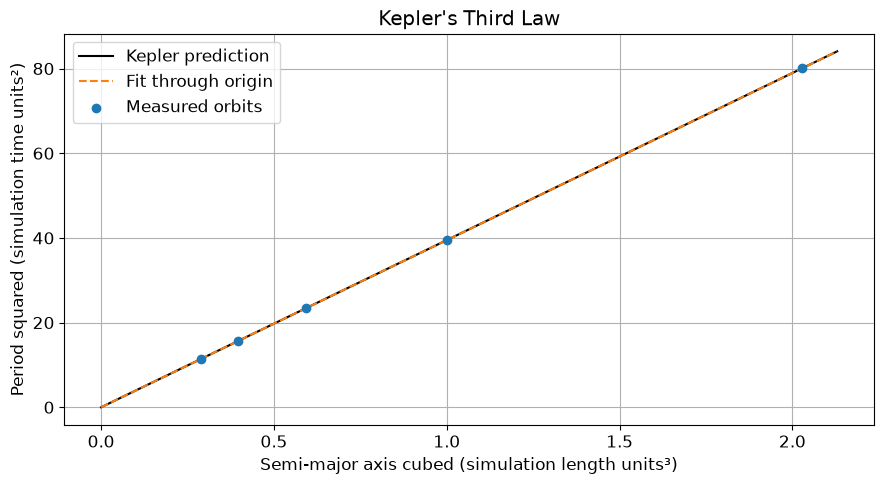


Predicted slope: 39.47841760
Fitted slope through origin: 39.47842055
Slope percentage error: 0.000007%
Free-fit slope: 39.47837688
Free-fit intercept: 5.78528349e-05


In [15]:
# Use five different initial speeds, all below escape speed.
kepler_speeds = [0.7, 0.8, 0.9, 1.0, 1.1]
kepler_dt = 0.001
kepler_duration = 60.0
kepler_steps = int(round(kepler_duration / kepler_dt))

# Keep the measurements for the later time-step comparison.
kepler_measurements = {}

print(
    f"{'Initial speed':>14} {'Measured a':>14} "
    f"{'Measured T':>14} {'T² / a³':>14} {'Periods used':>14}"
)

for speed in kepler_speeds:
    results = simulate(
        method="verlet",
        dt=kepler_dt,
        n_steps=kepler_steps,
        r_initial=[1.0, 0.0],
        v_initial=[0.0, speed],
    )

    measurement = measure_orbit(results)
    kepler_measurements[speed] = measurement

    measured_a = measurement["semi_major_axis"]
    measured_T = measurement["period"]
    ratio = measured_T**2 / measured_a**3

    print(
        f"{speed:>14.1f} {measured_a:>14.6f} "
        f"{measured_T:>14.6f} {ratio:>14.6f} "
        f"{len(measurement['period_samples']):>14}"
    )

# Collect the measured axes and periods into arrays.
measured_axes = np.array([
    kepler_measurements[speed]["semi_major_axis"]
    for speed in kepler_speeds
])

measured_periods = np.array([
    kepler_measurements[speed]["period"]
    for speed in kepler_speeds
])

a_cubed = measured_axes**3
T_squared = measured_periods**2

# Fit a line constrained to pass through the origin.
kepler_slope = np.dot(a_cubed, T_squared) / np.dot(a_cubed, a_cubed)
theory_slope = 4 * np.pi**2 / (G * M)

# Fit a second line with an unrestricted intercept.
free_slope, free_intercept = np.polyfit(a_cubed, T_squared, 1)

slope_percent_error = (
    100 * abs(kepler_slope - theory_slope) / theory_slope
)

# Plot the measurements and both the predicted and fitted relationships.
x_line = np.linspace(0, 1.05 * np.max(a_cubed), 200)

plt.figure(figsize=(9, 5))
plt.plot(
    x_line,
    theory_slope * x_line,
    color="black",
    label="Kepler prediction",
)
plt.plot(
    x_line,
    kepler_slope * x_line,
    "--",
    color="tab:orange",
    label="Fit through origin",
)
plt.scatter(
    a_cubed,
    T_squared,
    color="tab:blue",
    zorder=3,
    label="Measured orbits",
)

plt.xlabel("Semi-major axis cubed (simulation length units³)")
plt.ylabel("Period squared (simulation time units²)")
plt.title("Kepler's Third Law")
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nPredicted slope: {theory_slope:.8f}")
print(f"Fitted slope through origin: {kepler_slope:.8f}")
print(f"Slope percentage error: {slope_percent_error:.6f}%")
print(f"Free-fit slope: {free_slope:.8f}")
print(f"Free-fit intercept: {free_intercept:.8e}")

### Checking the effect of the time step

I will repeat all five orbits with the time step reduced from
0.001 to 0.0005, keeping the total duration at 60 time units.

I will compare the measured semi-major axes and periods between
the original and refined runs. I will also compare each measurement
with its analytical value:

$$
a_{\mathrm{exact}}=-\frac{GM}{2\varepsilon_0},
$$

$$
T_{\mathrm{exact}}
=2\pi\sqrt{\frac{a_{\mathrm{exact}}^3}{GM}}.
$$

These analytical values will serve as references for assessing
numerical error; the measured periods will still come from
the simulated axis crossings.

Velocity Verlet is second-order accurate, so its leading integration
errors should decrease by approximately a factor of four when the
time step is halved. Interpolation and sampling of the minimum
and maximum distances also contribute to the measured errors.

For the third-law ratio, small errors approximately satisfy:

$$
\frac{\delta(T^2/a^3)}{T^2/a^3}
\approx 2\frac{\delta T}{T}-3\frac{\delta a}{a}.
$$

Period and semi-major-axis errors can therefore partly cancel.
A very accurate fitted slope does not necessarily mean that
every individual measurement is equally accurate.

In [16]:
# Halve the time step while preserving the simulation duration.
refined_dt = kepler_dt / 2
refined_steps = int(round(kepler_duration / refined_dt))

refined_measurements = {}
accuracy_rows = []

for speed in kepler_speeds:
    results = simulate(
        method="verlet",
        dt=refined_dt,
        n_steps=refined_steps,
        r_initial=[1.0, 0.0],
        v_initial=[0.0, speed],
    )

    refined = measure_orbit(results)
    refined_measurements[speed] = refined
    original = kepler_measurements[speed]

    # Analytical reference values for this initial condition.
    exact_energy = specific_energy(
        np.array([1.0, 0.0]),
        np.array([0.0, speed]),
    )
    exact_a = -G * M / (2 * exact_energy)
    exact_T = 2 * np.pi * np.sqrt(exact_a**3 / (G * M))

    # Absolute percentage errors relative to the analytical values.
    a_error_old = (
        100 * abs(original["semi_major_axis"] - exact_a) / exact_a
    )
    a_error_new = (
        100 * abs(refined["semi_major_axis"] - exact_a) / exact_a
    )
    T_error_old = (
        100 * abs(original["period"] - exact_T) / exact_T
    )
    T_error_new = (
        100 * abs(refined["period"] - exact_T) / exact_T
    )

    accuracy_rows.append(
        (speed, a_error_old, a_error_new, T_error_old, T_error_new)
    )

print("Absolute percentage errors relative to analytical values:")
print(
    f"{'v0':>5} {'a: original':>15} {'a: refined':>15} "
    f"{'T: original':>15} {'T: refined':>15}"
)

for speed, a_old, a_new, T_old, T_new in accuracy_rows:
    print(
        f"{speed:>5.1f} {a_old:>15.6e} {a_new:>15.6e} "
        f"{T_old:>15.6e} {T_new:>15.6e}"
    )

# Repeat the third-law fit using the refined measurements.
refined_axes = np.array([
    refined_measurements[speed]["semi_major_axis"]
    for speed in kepler_speeds
])

refined_periods = np.array([
    refined_measurements[speed]["period"]
    for speed in kepler_speeds
])

refined_x = refined_axes**3
refined_y = refined_periods**2

refined_slope = (
    np.dot(refined_x, refined_y) / np.dot(refined_x, refined_x)
)

refined_slope_error = (
    100 * abs(refined_slope - theory_slope) / theory_slope
)

print(f"\nOriginal time step: {kepler_dt:.6f}")
print(f"Refined time step: {refined_dt:.6f}")
print(f"Predicted slope: {theory_slope:.10f}")
print(f"Original fitted slope: {kepler_slope:.10f}")
print(f"Refined fitted slope: {refined_slope:.10f}")
print(f"Original slope error: {slope_percent_error:.8f}%")
print(f"Refined slope error: {refined_slope_error:.8f}%")

Absolute percentage errors relative to analytical values:
   v0     a: original      a: refined     T: original      T: refined
  0.7    1.184931e-04    2.979358e-05    5.771879e-04    1.442982e-04
  0.8    6.066020e-05    1.516409e-05    1.848597e-04    4.621507e-05
  0.9    3.512067e-05    8.780607e-06    6.755721e-05    1.688933e-05
  1.0    2.499999e-05    6.249999e-06    3.333326e-05    8.333332e-06
  1.1    2.416770e-05    6.042516e-06    2.937757e-05    7.344417e-06

Original time step: 0.001000
Refined time step: 0.000500
Predicted slope: 39.4784176044
Original fitted slope: 39.4784205543
Refined fitted slope: 39.4784183384
Original slope error: 0.00000747%
Refined slope error: 0.00000186%


### Part C interpretation

The results agreed closely with all three of Kepler's laws.

For the first law, the simulated trajectory overlapped the predicted
ellipse. The measured semi-major axis was approximately 0.735295,
compared with the predicted 0.735294. The measured eccentricity
was 0.359999, compared with 0.360000.

For the second law, the calculated area swept per time step stayed
at approximately 0.0004, with deviations near floating-point
precision. This agrees with angular-momentum conservation because
the areal velocity equals half the magnitude of the specific
angular momentum.

For the third law, the five measured orbits followed a straight
line on the plot of period squared against semi-major axis cubed.
The fitted slope was 39.4784205543, compared with the theoretical
39.4784176044. The fit with a free intercept also gave an intercept
close to zero.

Halving the time step from 0.001 to 0.0005 reduced the errors in
both period and semi-major axis by approximately a factor of four.
The refined slope was 39.4784183384, with a percentage error of
approximately 0.00000186%. This behavior is consistent with the
second-order accuracy of Velocity Verlet.

The period measurements had larger relative errors than the
semi-major-axis measurements for all five orbits. The most
eccentric orbit, starting at speed 0.7, had the largest errors.
Its closer passage to the central body makes the motion harder
to resolve with a fixed time step.

The refinement results indicate that time-step-dependent errors
are important. However, this comparison does not completely
separate integration error from crossing interpolation and
sampling of the radial extremes. Both measurement procedures
also depend on the time step.

Finally, the very small fitted-slope error should not be taken
as the accuracy of every individual measurement. Errors in
period and semi-major axis can partly cancel in the ratio
$T^2/a^3$.

## Bonus: Three-Body Figure-Eight Orbit

### Model and initial conditions

I will simulate three equal point masses moving under their mutual
gravitational attraction. There will be no fixed central body and
no external forces.

I will use published initial conditions for the figure-eight
solution. With these specially chosen conditions, the three bodies
follow the same figure-eight path at different times.

All three masses and the gravitational constant will equal 1 in
the simulation units. The initial conditions place the center of
mass at the origin and give the system zero total momentum.
The center of mass should therefore remain at the origin.

I will reuse the Velocity Verlet function, supplying a new
acceleration function that accounts for all three bodies.
I will check total energy, momentum, and center-of-mass motion,
as well as how closely the configuration repeats.

Source for the numerical initial conditions:
[Richard Montgomery's figure-eight page](https://people.ucsc.edu/~rmont/NbdyB.html),
which credits Carles Simó.

In [17]:
# Reuse the list-of-body-dictionaries structure from the collision lab.
# These are point masses, so physical radii are not needed.
figure8_bodies = [
    {
        "m": 1.0,
        "r": np.array([-0.97000436, 0.24308753]),
        "v": np.array([-0.466203685, -0.432365730]),
    },
    {
        "m": 1.0,
        "r": np.array([0.97000436, -0.24308753]),
        "v": np.array([-0.466203685, -0.432365730]),
    },
    {
        "m": 1.0,
        "r": np.array([0.0, 0.0]),
        "v": np.array([0.932407370, 0.864731460]),
    },
]

# Collect the masses, positions, and velocities into arrays.
figure8_masses = np.array([body["m"] for body in figure8_bodies])
figure8_r0 = np.array([body["r"] for body in figure8_bodies])
figure8_v0 = np.array([body["v"] for body in figure8_bodies])

# Check the initial center of mass and total momentum.
initial_cm = np.zeros(2)
initial_momentum = np.zeros(2)

for body in figure8_bodies:
    initial_cm += body["m"] * body["r"]
    initial_momentum += body["m"] * body["v"]

initial_cm /= np.sum(figure8_masses)

print(f"Number of bodies: {len(figure8_bodies)}")
print("Masses:", figure8_masses)
print("Initial center of mass:", initial_cm)
print("Initial total momentum:", initial_momentum)
print("Position array shape:", figure8_r0.shape)

Number of bodies: 3
Masses: [1. 1. 1.]
Initial center of mass: [0. 0.]
Initial total momentum: [0. 0.]
Position array shape: (3, 2)


### Calculating mutual gravitational acceleration

For each pair of bodies, I will calculate their separation vector:

$$
\mathbf{d}=\mathbf{r}_j-\mathbf{r}_i.
$$

The resulting accelerations are:

$$
\mathbf{a}_i=\frac{Gm_j}{|\mathbf{d}|^3}\mathbf{d},
$$

$$
\mathbf{a}_j=-\frac{Gm_i}{|\mathbf{d}|^3}\mathbf{d}.
$$

These expressions give equal and opposite forces when multiplied
by the respective masses, as required by Newton's third law.

The function will begin with zero acceleration for every body,
then add the contributions from each pair. Each pair will be
checked once, updating both bodies' accelerations.

The returned array will have one row per body and two columns
for the x and y acceleration components. This will allow the
existing Verlet function to advance all three bodies together.

In [18]:
def figure8_accel(positions):
    """Return the acceleration of each body due to the other bodies."""

    # Start with zero acceleration for every body.
    accelerations = np.zeros_like(positions, dtype=float)
    n_bodies = len(positions)

    # Visit each unique pair once.
    for i in range(n_bodies):
        for j in range(i + 1, n_bodies):

            # Vector pointing from body i toward body j.
            separation = positions[j] - positions[i]
            distance = np.linalg.norm(separation)

            if distance == 0:
                raise ValueError(
                    "Two bodies occupy the same position."
                )

            # Common vector factor in the gravitational acceleration.
            gravity_vector = G * separation / distance**3

            # Add the mutual gravitational contributions.
            accelerations[i] += figure8_masses[j] * gravity_vector
            accelerations[j] -= figure8_masses[i] * gravity_vector

    return accelerations

### Calculating total energy

The system's total kinetic energy is the sum of the kinetic
energies of all three bodies:

$$
K=\sum_i \frac{1}{2}m_i|\mathbf{v}_i|^2.
$$

Its gravitational potential energy is:

$$
U=-\sum_{i<j}\frac{Gm_im_j}{|\mathbf{r}_j-\mathbf{r}_i|}.
$$

The condition $i<j$ counts each pair once. Counting both $(i,j)$
and $(j,i)$ would incorrectly double the potential energy.

The total mechanical energy is:

$$
E=K+U.
$$

Because there are no external forces or dissipative interactions,
the exact system should conserve total energy. Velocity Verlet
will introduce a small numerical error, which I will track
throughout the simulation.

This function returns total energy, rather than the energy
per unit mass used for the fixed-star orbits.

In [19]:
def figure8_energy(positions, velocities):
    """Return the total kinetic plus gravitational potential energy."""

    kinetic = 0.0
    potential = 0.0
    n_bodies = len(positions)

    # Add the kinetic energy of every body.
    for i in range(n_bodies):
        speed_squared = np.dot(velocities[i], velocities[i])
        kinetic += 0.5 * figure8_masses[i] * speed_squared

    # Add the potential energy of each unique pair.
    for i in range(n_bodies):
        for j in range(i + 1, n_bodies):
            distance = np.linalg.norm(positions[j] - positions[i])

            if distance == 0:
                raise ValueError(
                    "Potential energy is undefined for coincident bodies."
                )

            potential -= (
                G * figure8_masses[i] * figure8_masses[j] / distance
            )

    return kinetic + potential


# Check the initial total energy.
figure8_initial_energy = figure8_energy(figure8_r0, figure8_v0)

print(
    f"Initial total energy: {figure8_initial_energy:.6f} "
    "(simulation energy units)"
)

Initial total energy: -1.287142 (simulation energy units)


### Running the figure-eight simulation

I will simulate the three bodies for 20 time units using a time
step of 0.001.

At each step, Velocity Verlet will update all three positions,
calculate the new mutual gravitational accelerations, and update
all three velocities.

I will store the positions and velocities along with total energy,
total momentum, and center-of-mass position:

$$
\mathbf{P}=\sum_i m_i\mathbf{v}_i,
$$

$$
\mathbf{R}_{\mathrm{cm}}
=\frac{\sum_i m_i\mathbf{r}_i}{\sum_i m_i}.
$$

Since the initial momentum and center-of-mass position are zero
and there are no external forces, both should remain near zero.
Total energy should remain close to its initial value.

These stored results will let me plot the trajectories and check
whether the motion is consistent with the expected figure-eight
solution.

In [20]:
# Simulation settings.
figure8_dt = 0.001
figure8_steps = 20000
figure8_total_mass = np.sum(figure8_masses)

# Copy the initial state.
r = figure8_r0.copy()
v = figure8_v0.copy()
a = figure8_accel(r)

# Prepare arrays, including storage for the initial state.
figure8_time = np.arange(figure8_steps + 1) * figure8_dt

figure8_positions = np.zeros((figure8_steps + 1, 3, 2))
figure8_velocities = np.zeros((figure8_steps + 1, 3, 2))
figure8_energies = np.zeros(figure8_steps + 1)
figure8_momentum = np.zeros((figure8_steps + 1, 2))
figure8_cm = np.zeros((figure8_steps + 1, 2))

for step in range(figure8_steps + 1):

    # Store the current state.
    figure8_positions[step] = r
    figure8_velocities[step] = v
    figure8_energies[step] = figure8_energy(r, v)

    # Calculate total momentum and center of mass.
    for i in range(len(figure8_masses)):
        figure8_momentum[step] += figure8_masses[i] * v[i]
        figure8_cm[step] += figure8_masses[i] * r[i]

    figure8_cm[step] /= figure8_total_mass

    # Finish after storing the final state.
    if step == figure8_steps:
        break

    # Advance all three bodies using the existing Verlet function.
    r, v, a = verlet_step(r, v, a, figure8_dt, figure8_accel)

print(f"Simulation duration: {figure8_time[-1]:.3f} time units")
print(f"Stored time points: {len(figure8_time)}")
print(f"Initial total energy: {figure8_energies[0]:.6f}")
print(f"Final total energy: {figure8_energies[-1]:.6f}")
print("Final total momentum:", figure8_momentum[-1])
print("Final center of mass:", figure8_cm[-1])

Simulation duration: 20.000 time units
Stored time points: 20001
Initial total energy: -1.287142
Final total energy: -1.287142
Final total momentum: [4.66293670e-15 1.66533454e-16]
Final center of mass: [2.60532336e-14 6.47630098e-15]


### Plotting the figure-eight and checking conservation

I will plot each body's trajectory on the same axes and mark
their starting positions. The three paths should closely overlap
because the bodies follow the same figure-eight curve at
different times.

I will also plot total energy, its fractional deviation from
the initial value, and the displacement of the center of mass
from the origin.

The maximum energy error will check conservation over the entire
run. Since the expected total momentum and center-of-mass position
are zero, I will report their absolute magnitudes rather than
divide by their initial values.

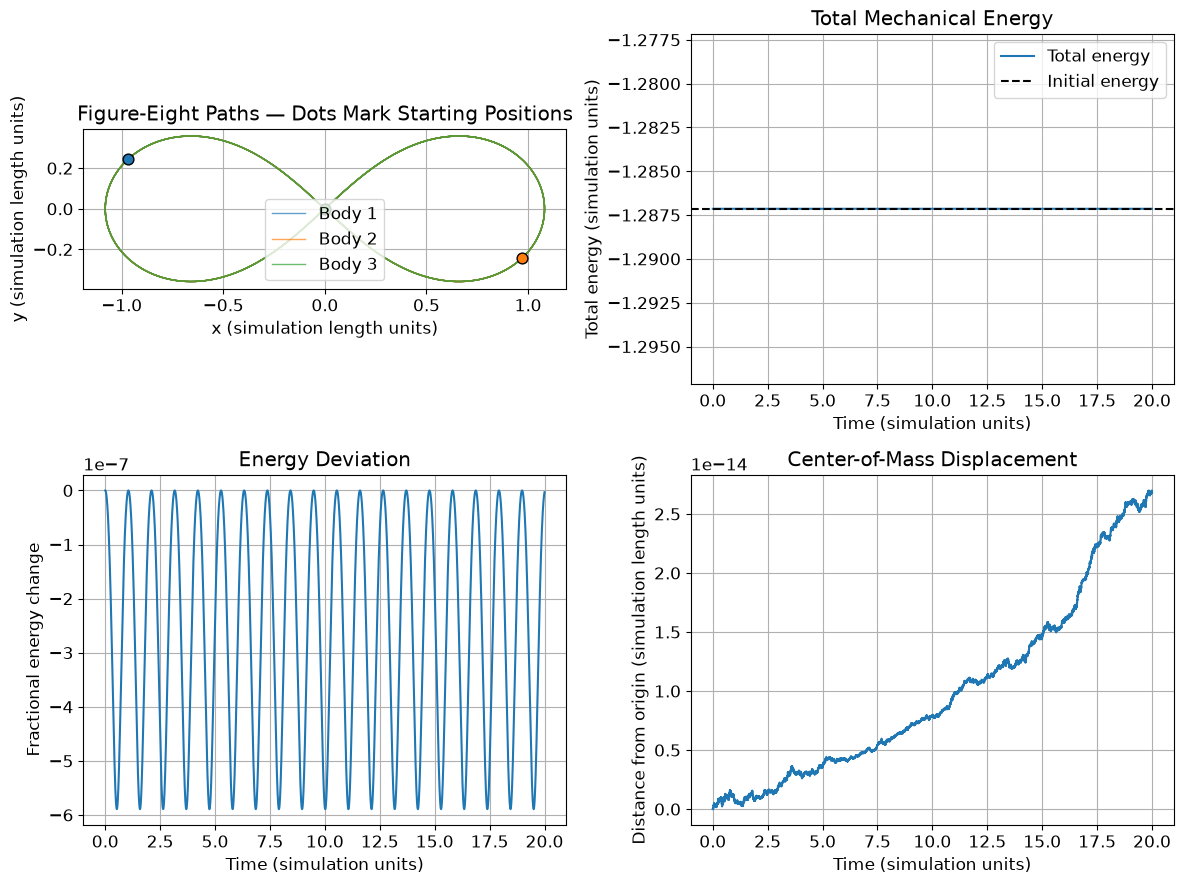

Maximum fractional energy error: 5.892e-07
Maximum total momentum magnitude: 1.401e-14
Maximum center-of-mass distance from origin: 2.699e-14


In [21]:
# Calculate conservation diagnostics over the entire simulation.
figure8_energy_change = (
    figure8_energies - figure8_energies[0]
) / abs(figure8_energies[0])

figure8_momentum_magnitude = np.linalg.norm(
    figure8_momentum, axis=1
)
figure8_cm_distance = np.linalg.norm(figure8_cm, axis=1)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
body_colors = ["tab:blue", "tab:orange", "tab:green"]

# Plot each body's trajectory and starting position.
for i, color in enumerate(body_colors):
    axes[0, 0].plot(
        figure8_positions[:, i, 0],
        figure8_positions[:, i, 1],
        color=color,
        alpha=0.7,
        linewidth=1,
        label=f"Body {i + 1}",
    )

    axes[0, 0].scatter(
        figure8_r0[i, 0],
        figure8_r0[i, 1],
        color=color,
        edgecolors="black",
        s=60,
        zorder=5,
    )

axes[0, 0].set(
    xlabel="x (simulation length units)",
    ylabel="y (simulation length units)",
    title="Figure-Eight Paths — Dots Mark Starting Positions",
)
axes[0, 0].set_aspect("equal", adjustable="box")
axes[0, 0].legend()

# Plot total energy with the initial value as a reference.
axes[0, 1].plot(
    figure8_time, figure8_energies, label="Total energy"
)
axes[0, 1].axhline(
    figure8_energies[0],
    color="black",
    linestyle="--",
    label="Initial energy",
)
axes[0, 1].set(
    xlabel="Time (simulation units)",
    ylabel="Total energy (simulation units)",
    title="Total Mechanical Energy",
    ylim=(figure8_energies[0] - 0.01,
          figure8_energies[0] + 0.01),
)
axes[0, 1].legend()

# Magnify the small energy deviations.
axes[1, 0].plot(figure8_time, figure8_energy_change)
axes[1, 0].set(
    xlabel="Time (simulation units)",
    ylabel="Fractional energy change",
    title="Energy Deviation",
)

# Check whether the center of mass stays at the origin.
axes[1, 1].plot(figure8_time, figure8_cm_distance)
axes[1, 1].set(
    xlabel="Time (simulation units)",
    ylabel="Distance from origin (simulation length units)",
    title="Center-of-Mass Displacement",
)

plt.tight_layout()
plt.show()

print(
    "Maximum fractional energy error: "
    f"{np.max(np.abs(figure8_energy_change)):.3e}"
)
print(
    "Maximum total momentum magnitude: "
    f"{np.max(figure8_momentum_magnitude):.3e}"
)
print(
    "Maximum center-of-mass distance from origin: "
    f"{np.max(figure8_cm_distance):.3e}"
)

### Checking whether the configuration repeats

A periodic solution should return each labeled body to its initial
position and velocity after one full period.

I will calculate the root-mean-square position difference from
the initial configuration:

$$
D_r(t)=
\sqrt{\frac{1}{3}\sum_{i=1}^{3}
|\mathbf{r}_i(t)-\mathbf{r}_i(0)|^2}.
$$

I will search for the smallest value between 1 and 10 time units.
This excludes the trivial match at the start and provides a window
for finding the first full return.

At the closest sampled return, I will also calculate the
root-mean-square velocity difference. Small differences in both
position and velocity would support approximate repetition.

The return time will be limited to the stored time grid. A small
mismatch can therefore result from sampling between exact returns,
as well as integration error and the rounded initial conditions.
This is a numerical check over a finite run, not a proof of exact
periodicity.

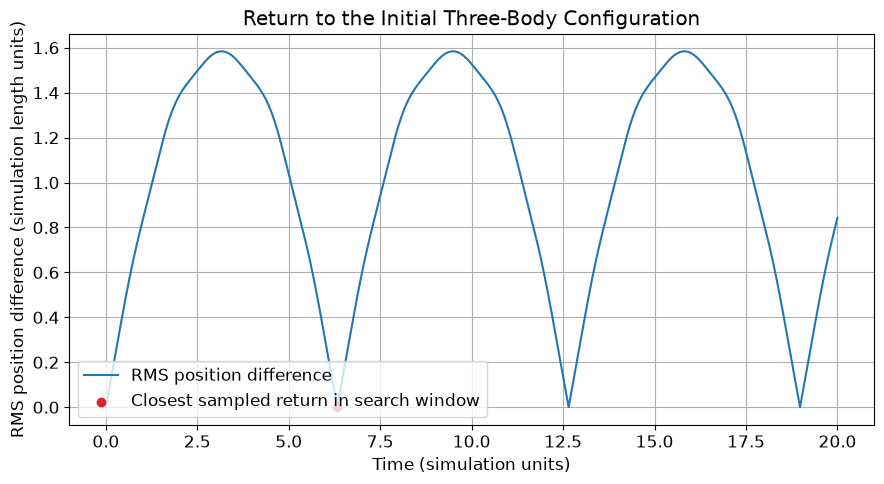

Closest sampled return time: 6.326000
RMS position difference at return: 7.589115e-05
RMS velocity difference at return: 8.550978e-05
Time-grid spacing: 0.001000


In [22]:
# Calculate each body's displacement from its own initial position.
position_difference = figure8_positions - figure8_r0

# Sum squared x and y differences, average over bodies, then take the root.
position_return_error = np.sqrt(
    np.mean(
        np.sum(position_difference**2, axis=2),
        axis=1,
    )
)

# Search a window that excludes the initial match.
search_indices = np.where(
    (figure8_time >= 1.0) & (figure8_time <= 10.0)
)[0]

best_index = search_indices[
    np.argmin(position_return_error[search_indices])
]

return_time = figure8_time[best_index]

# Check velocities at the same time as the closest position match.
velocity_difference = (
    figure8_velocities[best_index] - figure8_v0
)

velocity_return_error = np.sqrt(
    np.mean(np.sum(velocity_difference**2, axis=1))
)

plt.figure(figsize=(9, 5))
plt.plot(
    figure8_time,
    position_return_error,
    label="RMS position difference",
)
plt.scatter(
    return_time,
    position_return_error[best_index],
    color="tab:red",
    zorder=3,
    label="Closest sampled return in search window",
)
plt.xlabel("Time (simulation units)")
plt.ylabel("RMS position difference (simulation length units)")
plt.title("Return to the Initial Three-Body Configuration")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Closest sampled return time: {return_time:.6f}")
print(
    "RMS position difference at return: "
    f"{position_return_error[best_index]:.6e}"
)
print(f"RMS velocity difference at return: {velocity_return_error:.6e}")
print(f"Time-grid spacing: {figure8_dt:.6f}")

### Bonus interpretation

The three equal masses traced closely overlapping figure-eight
paths while occupying different positions along the curve.
This reproduced the expected shape using mutual gravitational
acceleration and the same Velocity Verlet function used earlier.

Total energy stayed close to -1.287142, with a maximum fractional
error of approximately $5.892\times10^{-7}$. The energy error
showed small repeating variations rather than an obvious
accumulating drift over the simulated interval.

The maximum total momentum magnitude was approximately
$1.401\times10^{-14}$, and the center of mass stayed within
$2.699\times10^{-14}$ length units of the origin. These small
deviations are consistent with floating-point rounding and
support the expected behavior of an isolated system.

The closest sampled return to the initial configuration occurred
at 6.326 time units. At that time, the RMS position difference
was approximately $7.59\times10^{-5}$ length units, and the RMS
velocity difference was approximately $8.55\times10^{-5}$
velocity units. Further near-returns appeared at roughly equal
intervals, supporting approximately periodic motion.

The return differences include time-grid sampling effects,
integration error, and the finite precision of the published
initial conditions. The results support the figure-eight
solution over this run, but they do not prove exact periodicity
or establish long-term stability.

This bonus also showed why separating the integrator from the
force calculation was useful. The Verlet update did not need
to change when moving from a fixed central body to three
mutually interacting bodies.